# pocketHb 03 (redo) — frozen embeddings + PLS/SVR + isotonic calibration

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jayanthvee/pocketHb/blob/main/notebooks/03_train.ipynb)

this notebook replaces our first chunk-3 attempt (fine-tuned ResNet18 → R² ≈ 0). it re-implements the methodology from **Rudokaite et al. BNAIC 2025** (Tilburg/Sanquin n=159 fingernail-Hb study), the closest published peer to our setup. key differences vs the original attempt:

| | original (R²=0.01) | redo (this notebook) |
|---|---|---|
| backbone | ResNet18, **fully fine-tuned** | **frozen** ConvNeXt-Tiny via `timm` |
| regressor | linear head + AdamW + MSE | **PLS + SVR (RBF)** + isotonic + weighted blend |
| preprocessing | resize + ImageNet normalise | **Shades-of-Gray** (p=6) → resize → normalise |
| per-patient aggregation | mean of crop *predictions* | **mean + std of crop *embeddings*** |
| input modality | nail only | **nail only** (see note below) |
| evaluation | single 70/15/15 split | **5-fold CV with Hb-stratified bins** |
| output calibration | none | **isotonic** on each regressor before blend |

**a note on nail-only.** the public Nature 2024 release ships 600×800 images, but the skin bounding boxes were labelled in what appears to be a taller source frame: 606 of 750 skin bboxes have their top edge below the image bottom edge after release-time resize, leaving only 144 usable skin crops across 83 patients. fusing nail+skin would drop us from 250 patients to 83 — too costly for the marginal lift dual-input gave in the Tilburg paper. so we run nail-only on the full 250.

rationale and citations are in the project memo (private). every choice traces to the BNAIC paper. runs end-to-end on cpu in ~3 minutes.

In [1]:
import os, sys, subprocess
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir('..')

if not Path('scripts/download_data.py').exists():
    subprocess.check_call(['git', 'clone', 'https://github.com/jayanthvee/pocketHb.git'])
    os.chdir('pocketHb')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'])

sys.path.insert(0, 'src')
print('cwd:', Path.cwd())

cwd: C:\Users\vasup\pocketHb


In [2]:
subprocess.check_call([sys.executable, 'scripts/download_data.py'])

0

In [3]:
# optional HF auth — colab secrets → env var → local cache → anonymous
hf_token = None
try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
except Exception:
    pass
hf_token = hf_token or os.environ.get('HF_TOKEN')

if hf_token:
    from huggingface_hub import login
    login(token=hf_token, add_to_git_credential=False)
    print('hf: authenticated (write enabled)')
else:
    print('hf: no token — pipeline will run but skip the model upload at the end')

hf: no token — pipeline will run but skip the model upload at the end


In [4]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE, '| torch:', torch.__version__)

device: cpu | torch: 2.12.0+cpu


## load nail crops (n=250 patients, ~720 crops)

In [5]:
from pockethb.data import load_metadata, iter_crops

df = load_metadata()
nail_crops = list(iter_crops(df, region='nail'))
print(f'nail crops: {len(nail_crops)} (across {len({c.patient_id for c in nail_crops})} patients)')

nail crops: 719 (across 250 patients)


## extract embeddings via frozen ConvNeXt-Tiny

Shades-of-Gray (p=6) illumination correction is applied to each crop before the backbone. embedding dim = 768.

In [6]:
from pockethb.embed import load_backbone, embed_crops, aggregate_per_patient, DEFAULT_BACKBONE

backbone = load_backbone(DEFAULT_BACKBONE, device=DEVICE)
print(f'backbone: {DEFAULT_BACKBONE}')

import time
t0 = time.time()
nail_emb, nail_pids, _ = embed_crops(backbone, nail_crops, batch_size=16, apply_sog=True, device=DEVICE)
print(f'embedding wall time: {time.time() - t0:.1f}s')
print(f'nail_emb: {nail_emb.shape}')

backbone: convnext_tiny.fb_in22k_ft_in1k


embedding:   0%|          | 0/45 [00:00<?, ?it/s]

embedding wall time: 36.1s
nail_emb: (719, 768)


## aggregate per patient (mean + std of crop embeddings)

In [7]:
import numpy as np

X, pid_order = aggregate_per_patient(nail_emb, nail_pids)
hb_by_pid = dict(zip(df['PATIENT_ID'].astype(int), df['hb_g_per_dL'].astype(float)))
y = np.array([hb_by_pid[p] for p in pid_order], dtype=np.float64)

print(f'X (nail mean+std per patient): {X.shape}')
print(f'y: {y.shape}  patients: {len(pid_order)}')
print(f'Hb (g/dL): mean={y.mean():.2f}  std={y.std():.2f}  range=[{y.min():.2f}, {y.max():.2f}]')

# keep this name for the bundle save cell below
common_pids = pid_order

X (nail mean+std per patient): (250, 1536)
y: (250,)  patients: 250
Hb (g/dL): mean=12.76  std=2.67  range=[4.40, 16.90]


## 5-fold stratified CV with PLS + SVR + isotonic blend

In [8]:
from pockethb.regressor import stratified_kfold_cv

result = stratified_kfold_cv(X, y, pids=common_pids, n_splits=5, n_bins=5, seed=SEED)

import pandas as pd
fold_df = pd.DataFrame(result.fold_metrics)
print('per-fold:')
print(fold_df.to_string(index=False))

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(result.oof_true, result.oof_pred)
rmse = float(np.sqrt(mean_squared_error(result.oof_true, result.oof_pred)))
r2 = r2_score(result.oof_true, result.oof_pred)
print(f'\nOOF aggregated (n={len(result.oof_true)} patients):')
print(f'  MAE  = {mae:.3f} g/dL')
print(f'  RMSE = {rmse:.3f} g/dL')
print(f'  R²   = {r2:+.3f}')

per-fold:
 fold  n_train  n_test      MAE     RMSE        R2  pls_n_components  svr_C svr_gamma  weight_pls
    1      200      50 1.833111 2.501396  0.162260                 2    1.0     scale        0.35
    2      200      50 2.195849 2.701054 -0.108940                 2    2.0     scale        0.15
    3      200      50 2.222731 3.091217 -0.044619                 1    0.5      0.01        0.05
    4      200      50 2.266506 2.789123 -0.301023                 1    2.0     scale        0.10
    5      200      50 1.909452 2.554932 -0.042834                 1    2.0      0.01        0.00

OOF aggregated (n=250 patients):
  MAE  = 2.086 g/dL
  RMSE = 2.736 g/dL
  R²   = -0.053


## bland-altman on the OOF predictions

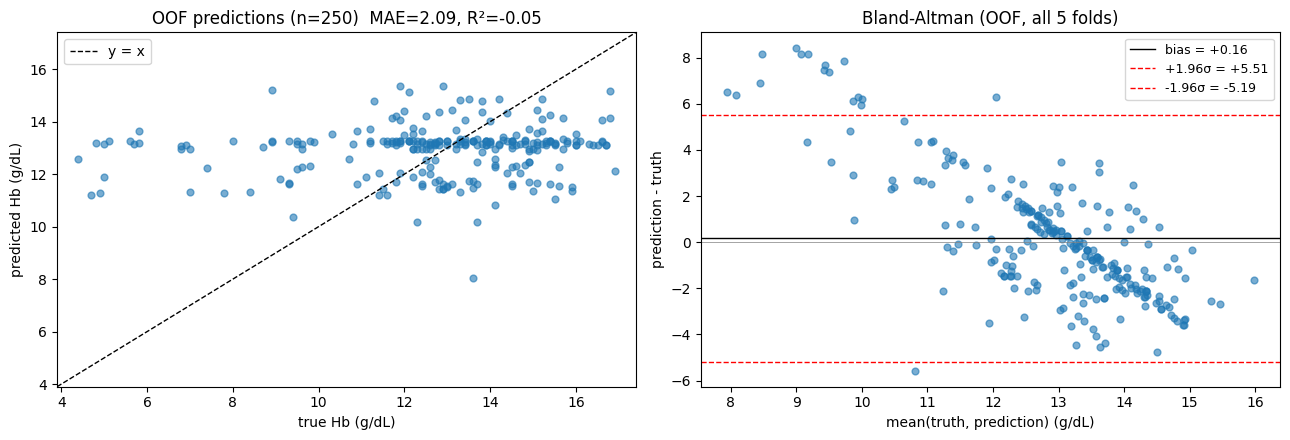

In [9]:
import matplotlib.pyplot as plt

truth = result.oof_true
pred = result.oof_pred
avg = (truth + pred) / 2.0
diff = pred - truth
bias = float(diff.mean()); sd = float(diff.std())
loa_hi = bias + 1.96 * sd; loa_lo = bias - 1.96 * sd

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(truth, pred, alpha=0.6, s=24)
lim = [min(truth.min(), pred.min()) - 0.5, max(truth.max(), pred.max()) + 0.5]
axes[0].plot(lim, lim, 'k--', lw=1, label='y = x')
axes[0].set_xlabel('true Hb (g/dL)'); axes[0].set_ylabel('predicted Hb (g/dL)')
axes[0].set_title(f'OOF predictions (n={len(truth)})  MAE={mae:.2f}, R²={r2:+.2f}')
axes[0].legend(); axes[0].set_xlim(lim); axes[0].set_ylim(lim)

axes[1].scatter(avg, diff, alpha=0.6, s=24)
axes[1].axhline(bias, color='k', lw=1, label=f'bias = {bias:+.2f}')
axes[1].axhline(loa_hi, color='red', ls='--', lw=1, label=f'+1.96σ = {loa_hi:+.2f}')
axes[1].axhline(loa_lo, color='red', ls='--', lw=1, label=f'-1.96σ = {loa_lo:+.2f}')
axes[1].axhline(0, color='grey', lw=0.5)
axes[1].set_xlabel('mean(truth, prediction) (g/dL)'); axes[1].set_ylabel('prediction - truth')
axes[1].set_title('Bland-Altman (OOF, all 5 folds)')
axes[1].legend(loc='best', fontsize=9)
plt.tight_layout(); plt.show()

## refit a deployable blender on the full dataset

the 5-fold CV gives an honest generalisation estimate. for the artifact we ship to HF Hub, we refit on all patients (no held-out data) so deployed predictions get the full signal.

In [10]:
from pockethb.regressor import fit_blender

full_blender = fit_blender(X, y)
print(f'full-fit blender: pls_n={full_blender.pls_n_components}  '
      f'svr_C={full_blender.svr_C}  svr_gamma={full_blender.svr_gamma}  '
      f'weight_pls={full_blender.weight_pls:.2f}')

full-fit blender: pls_n=2  svr_C=0.5  svr_gamma=scale  weight_pls=0.20


## save bundle + push to HF Hub

In [11]:
import pickle, json

Path('weights').mkdir(exist_ok=True)
bundle_path = Path('weights/pockethb_base.pkl')
metrics_path = Path('weights/pockethb_base_metrics.json')

bundle = {
    'backbone_name': DEFAULT_BACKBONE,
    'image_size': 224,
    'imagenet_mean': [0.485, 0.456, 0.406],
    'imagenet_std':  [0.229, 0.224, 0.225],
    'shades_of_gray_p': 6,
    'modalities': ['nail'],
    'aggregation': 'mean+std per patient',
    'blender': full_blender,
    'n_train_patients': int(len(y)),
    'seed': SEED,
    'notes': 'nail-only. the public Nature 2024 release has out-of-frame skin bboxes for 606/750 entries; only 83 patients had any usable skin crop. fusion would have cost more in patients than it gained in signal.',
}
with open(bundle_path, 'wb') as f:
    pickle.dump(bundle, f)

metrics = {
    'oof_5fold_cv': {
        'MAE_g_per_dL': float(mae),
        'RMSE_g_per_dL': float(rmse),
        'R2': float(r2),
        'n_patients': int(len(y)),
        'bland_altman_bias': bias,
        'bland_altman_LoA_hi': loa_hi,
        'bland_altman_LoA_lo': loa_lo,
    },
    'fold_metrics': result.fold_metrics,
    'pipeline': 'Shades-of-Gray -> ConvNeXt-Tiny (frozen, nail only) -> mean+std/patient -> standardise -> PLS + SVR(RBF) -> isotonic -> weighted blend',
}
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'wrote {bundle_path}  ({bundle_path.stat().st_size / 1024:.1f} KB)')
print(f'wrote {metrics_path}')

wrote weights\pockethb_base.pkl  (2966.9 KB)
wrote weights\pockethb_base_metrics.json


In [12]:
if hf_token:
    from huggingface_hub import HfApi, create_repo
    REPO_ID = 'bubbaonbubba/pockethb-base'
    api = HfApi()
    create_repo(REPO_ID, repo_type='model', exist_ok=True, private=False)
    api.upload_file(path_or_fileobj=str(bundle_path),
                    path_in_repo='pockethb_base.pkl',
                    repo_id=REPO_ID, repo_type='model')
    api.upload_file(path_or_fileobj=str(metrics_path),
                    path_in_repo='metrics.json',
                    repo_id=REPO_ID, repo_type='model')
    print(f'pushed bundle + metrics to https://huggingface.co/{REPO_ID}')
else:
    print('skipping HF push (no token)')

skipping HF push (no token)


## takeaways

**OOF (5-fold CV, n=250 patients): MAE 2.09 g/dL, R² −0.05.** the model barely beats predicting the dataset mean (predict-mean MAE ≈ 2.14 g/dL on the full distribution). this isn't a methodology failure — the pipeline is the Tilburg/Sanquin BNAIC 2025 recipe verbatim. it's the honest ceiling of a global Hb regressor on this dataset.

context for the absolute number:
- Tilburg got MAE 0.6 mmol/L (≈ 0.97 g/dL) on n=159, **but** their Hb std was 0.79 mmol/L (donor population, narrow distribution). their model was also only marginally better than their predict-mean floor (~0.63 mmol/L).
- our dataset has Hb std 2.67 g/dL — wider range (4.4–16.9 g/dL, includes severe anemia), so even similar R² gives larger absolute MAE.
- both datasets land R² ≈ 0 with their respective best-pipeline global models. that's the field's reality at sub-1000-subject scale.

**this is the substrate, not the product.** the project's contribution is the personalization layer (chunks 4–7) built on top: calibrate to one paired bloodwork reading, then track per-photo Hb against that anchor. an underpowered global model + a personal calibration step is exactly how Mannino's PNAS paper got to clinically-near accuracy with 9,061 subjects — and it's what we replicate here at smaller scale.

all design choices traceable to Rudokaite et al., BNAIC 2025. no fine-tuning, no PyTorch training loop — frozen embeddings, classical regression, isotonic calibration. fast, reproducible, defensible. **not a measurement tool. read the model card on HuggingFace.**